In [ ]:
pip install --upgrade --user anndata scanpy h5py

In [ ]:
!pip install --upgrade anndata==0.12.2

In [ ]:
pip install --user scvi-tools

In [ ]:
pip install --user wget

In [28]:
import sys
import warnings

import scvi
import re
import wget
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata as ad
from anndata import AnnData

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

sc.settings.set_figure_params(dpi=80)
%matplotlib inline

data_path = './xenium_ctnnd2_vc/data'

In [3]:
adata_8M  = ad.read_h5ad(f'{data_path}/8M_WT_VC_subset_cleaned.h5ad')
adata_1M  = ad.read_h5ad(f'{data_path}/1M_KO_VC_subset_cleaned.h5ad')
adata_2F  = ad.read_h5ad(f'{data_path}/2F_WT_VC_subset_cleaned.h5ad')
adata_7F  = ad.read_h5ad(f'{data_path}/7F_KO_VC_subset_cleaned.h5ad')

In [7]:
## Add some annotations for condition and Sample ID
adata_8M.obs['condition'] = 'WT'
adata_1M.obs['condition'] = 'KO'
adata_2F.obs['condition'] = 'WT'
adata_7F.obs['condition'] = 'KO'

adata_8M.obs['sample_id'] = '8M_WT'
adata_1M.obs['sample_id'] = '1M_KO'
adata_2F.obs['sample_id'] = '2F_WT'
adata_7F.obs['sample_id'] = '7F_KO'

In [8]:
## Make cell indices unique by adding a sample-specific prefix
adata_8M.obs_names = ["8M_" + str(i) for i in adata_8M.obs_names]
adata_1M.obs_names = ["1M_" + str(i) for i in adata_1M.obs_names]
adata_2F.obs_names = ["2F_" + str(i) for i in adata_2F.obs_names]
adata_7F.obs_names = ["7F_" + str(i) for i in adata_7F.obs_names]

In [14]:
# Assuming you have multiple AnnData objects named adata1, adata2, adata3
adatas_to_combine = [adata_8M, adata_1M, adata_2F, adata_7F]

# Concatenate along the observations axis (axis=0)
# 'batch_key' adds a column to .obs indicating the origin of each observation
# 'uns_merge="unique"' handles merging of unstructured data
adata_concat = ad.concat(
    adatas_to_combine,
    axis=0,
    join='outer',  # Use 'outer' to keep all features present in any object
    #batch_key='sample_id', # Adds a column to .obs to identify original samples
    #batch_categories=['8M_KO', '1M_KO', '2F_WT', '7F_KO'], # Optional: specify categories
    uns_merge="unique"
)

In [15]:
adata_concat.layers['counts'] = adata_concat.X

In [12]:
adata_concat.write(f'{data_path}/adata_xenium_combined_uncorrected.h5ad')

In [35]:
#OPTIONAL if reproducing exact plots from submitted manuscript
#SKIP this cell if you are starting from scratch
#revert to UMAP representation previously computed for submitted manuscript
## Read in raw concatenated xenium data

xenium_data_path = "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 5 and S4/xenium_dataset/GEO_submission/anndata_objects"
adata_concat = ad.read_h5ad(f'{xenium_data_path}/adata_xenium_combined_uncorrected.h5ad')

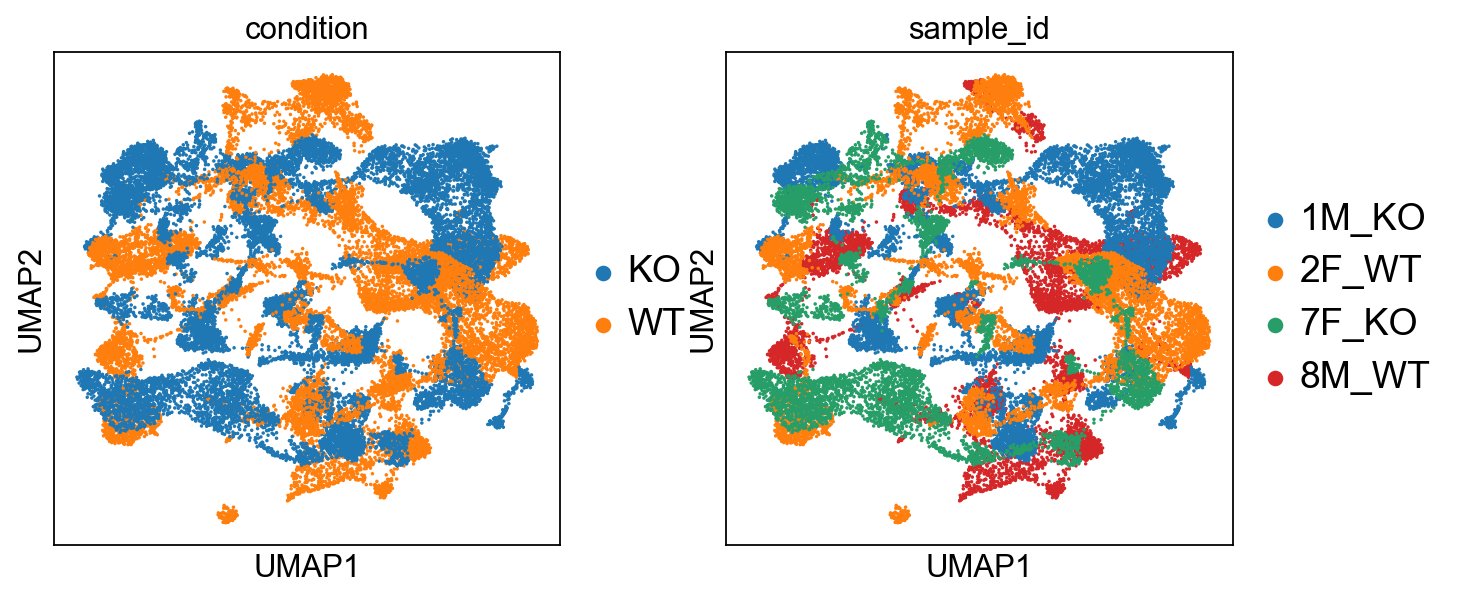

In [36]:
## Plot initial UMAP to check cell segregation by sample
sc.pl.umap(adata_concat, color = ['condition', 'sample_id'], size = 10, legend_fontsize = 'large', cmap = 'plasma')

## Use SCVI to account for batch effects and integrate data

In [17]:
adata_scvi = adata_concat
batch_key = 'sample_id'
adata_scvi

AnnData object with n_obs × n_vars = 31469 × 331
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden_res0_25', 'leiden_res0_1', 'leiden_res0_5', 'leiden_res0_75', 'condition', 'sample_id', 'leiden_res1_25', 'leiden_res1_0'
    uns: 'leiden_res0_1', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res0_75', 'neighbors', 'pca', 'spatialdata_attrs', 'umap', 'leiden_res0_1_colors', 'leiden_res1_0', 'leiden_res1_0_colors', 'leiden_res1_25', 'leiden_res1_25_colors', 'condition_colors', 'sample_id_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    l

In [18]:
# integration should be performed on normalized and log-transformed data, with normalization being set to a fixed number of counts per cell. 
sc.pp.normalize_total(adata_scvi, target_sum=1e4)
sc.pp.log1p(adata_scvi)

normalizing counts per cell
    finished (0:00:00)


In [19]:
# It is also recommended that data be subsetted to HVGs before integration
sc.pp.highly_variable_genes(
    adata_scvi, n_top_genes=2000, flavor="cell_ranger", batch_key=batch_key
)
adata_scvi
adata_scvi.var

extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
`n_top_genes` > `adata.n_var`, returning all genes.
`n_top_genes` > `adata.n_var`, returning all genes.
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection
2010300C02Rik,True,2.922239,1.949870,-0.777868,4,True
2610035D17Rik,True,0.692436,3.406822,-1.041899,4,True
Acsbg1,True,1.721707,2.999472,1.009603,4,True
Acsl3,True,1.523887,2.825462,-0.418374,4,True
Acta2,True,0.546902,3.794813,-0.257628,4,True
...,...,...,...,...,...,...
Zeb1,True,0.813379,3.466359,-0.685549,4,True
Zfp366,True,0.249673,4.745310,0.971113,4,True
Zfp462,True,0.699036,3.412865,-1.020081,4,True
Zfp536,True,0.908292,3.843643,0.843284,4,True


In [20]:
# check how many batches each gene is detected as an HVG. Ideally you want to use HVGs shared by all batches.
n_batches = adata_scvi.var["highly_variable_nbatches"].value_counts()
n_batches

highly_variable_nbatches
4    326
3      3
1      1
2      1
Name: count, dtype: int64

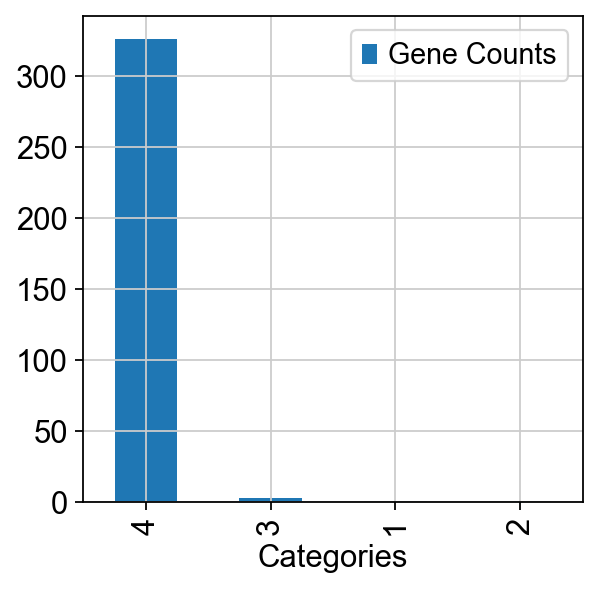

In [21]:
barplot = pd.DataFrame({'Categories':['4','3','1', '2'],'Gene Counts':n_batches.to_list()})
ax = barplot.plot.bar(x='Categories', y='Gene Counts')
plt.show()

In [22]:
adata_scvi_hvg = adata_scvi[:, adata_scvi.var["highly_variable"]].copy()
adata_scvi_hvg

AnnData object with n_obs × n_vars = 31469 × 331
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden_res0_25', 'leiden_res0_1', 'leiden_res0_5', 'leiden_res0_75', 'condition', 'sample_id', 'leiden_res1_25', 'leiden_res1_0'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'leiden_res0_1', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res0_75', 'neighbors', 'pca', 'spatialdata_attrs', 'umap', 'leiden_res0_1_colors', 'leiden_res1_0', 'leiden_res1_0_colo

In [39]:
# keep only HVGs and freeze normalized log-transformed counts in counts layer (in this case all genes are included as HVGs because there are only 331 and the default target number is 2000
adata_scvi = adata_scvi_hvg.copy()
adata_scvi.layers["counts"] = adata_scvi.X

In [23]:
# set up SCVI model (use HVG counts and set batch variable)
import scvi
scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key=batch_key)
adata_scvi

C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\scvi\data\fields\_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


AnnData object with n_obs × n_vars = 31469 × 331
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden_res0_25', 'leiden_res0_1', 'leiden_res0_5', 'leiden_res0_75', 'condition', 'sample_id', 'leiden_res1_25', 'leiden_res1_0', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'leiden_res0_1', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res0_75', 'neighbors', 'pca', 'spatialdata_attrs', 'umap', 'leiden_res0_1_colors', 'leid

In [24]:
model_scvi = scvi.model.SCVI(adata_scvi)
model_scvi

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [24]:
model_scvi.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': 'counts',
│   'batch_key': 'sample_id',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   4   │
│         n_cells          │ 31469 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │  331  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │  adata.layers['counts']   │
│    batch     │ adata.obs['_scvi_batch']  │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                    batch State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample_id'] │   1M_KO    │          0          │
│                        │   2F_WT    │          1          │
│                        │   7F_KO    │          2          │
│                        │   8M_WT    │          3          │
└────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

In [25]:
max_epochs_scvi = np.min([round((20000 / adata_scvi.n_obs) * 400), 400])
max_epochs_scvi

np.int64(254)

In [26]:
model_scvi.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 1/254:   0%|                                                                             | 0/254 [00:00<?, ?it/s]

C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\scvi\module\_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\scvi\module\_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


Epoch 2/254:   0%|                 | 1/254 [00:02<11:57,  2.84s/it, v_num=1, train_loss_step=174, train_loss_epoch=188]

C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\scvi\module\_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\scvi\module\_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


...

Epoch 254/254: 100%|████████████▉| 253/254 [11:11<00:02,  2.59s/it, v_num=1, train_loss_step=143, train_loss_epoch=149]

C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\scvi\module\_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
C:\Users\Gabrielle\AppData\Roaming\Python\Python310\site-packages\scvi\module\_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


Epoch 254/254: 100%|█████████████| 254/254 [11:14<00:00,  2.61s/it, v_num=1, train_loss_step=144, train_loss_epoch=149]

`Trainer.fit` stopped: `max_epochs=254` reached.


Epoch 254/254: 100%|█████████████| 254/254 [11:14<00:00,  2.65s/it, v_num=1, train_loss_step=144, train_loss_epoch=149]


In [27]:
adata_scvi.obsm["X_scVI"] = model_scvi.get_latent_representation()
sc.pp.neighbors(adata_scvi, use_rep="X_scVI")
sc.tl.umap(adata_scvi)
adata_scvi

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:27)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:13)


AnnData object with n_obs × n_vars = 31469 × 331
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden_res0_25', 'leiden_res0_1', 'leiden_res0_5', 'leiden_res0_75', 'condition', 'sample_id', 'leiden_res1_25', 'leiden_res1_0', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'leiden_res0_1', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res0_75', 'neighbors', 'pca', 'spatialdata_attrs', 'umap', 'leiden_res0_1_colors', 'leid

In [33]:
#OPTIONAL if reproducing exact plots from submitted manuscript
#SKIP this cell if you are starting from scratch
#revert to UMAP representation previously computed for submitted manuscript
## Read in batch-corrected xenium data

xenium_data_path = "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 5 and S4/xenium_dataset/GEO_submission/anndata_objects"
puck = ad.read_h5ad(f'{xenium_data_path}/adata_scvi_xenium_batchcorrected.h5ad')

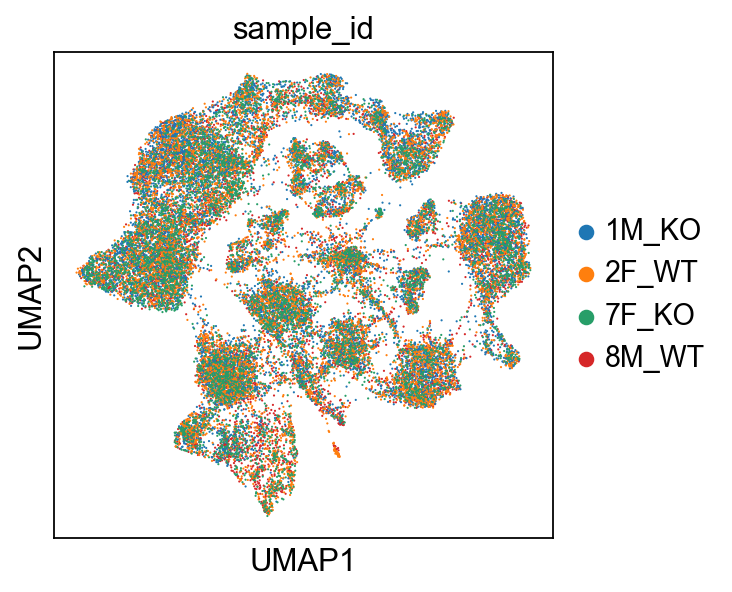

In [34]:
sc.pl.umap(adata_scvi, color=[batch_key], wspace=1)

## Clustering and annotation

running Leiden clustering


C:\Users\Gabrielle\AppData\Local\Temp\ipykernel_27520\2842845088.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_scvi, key_added='leiden_res0_25', resolution=0.25)


    finished: found 17 clusters and added
    'leiden_res0_25', the cluster labels (adata.obs, categorical) (0:00:02)
running Leiden clustering
    finished: found 19 clusters and added
    'leiden_res0_35', the cluster labels (adata.obs, categorical) (0:00:02)
running Leiden clustering
    finished: found 10 clusters and added
    'leiden_res0_1', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering
    finished: found 20 clusters and added
    'leiden_res0_5', the cluster labels (adata.obs, categorical) (0:00:02)


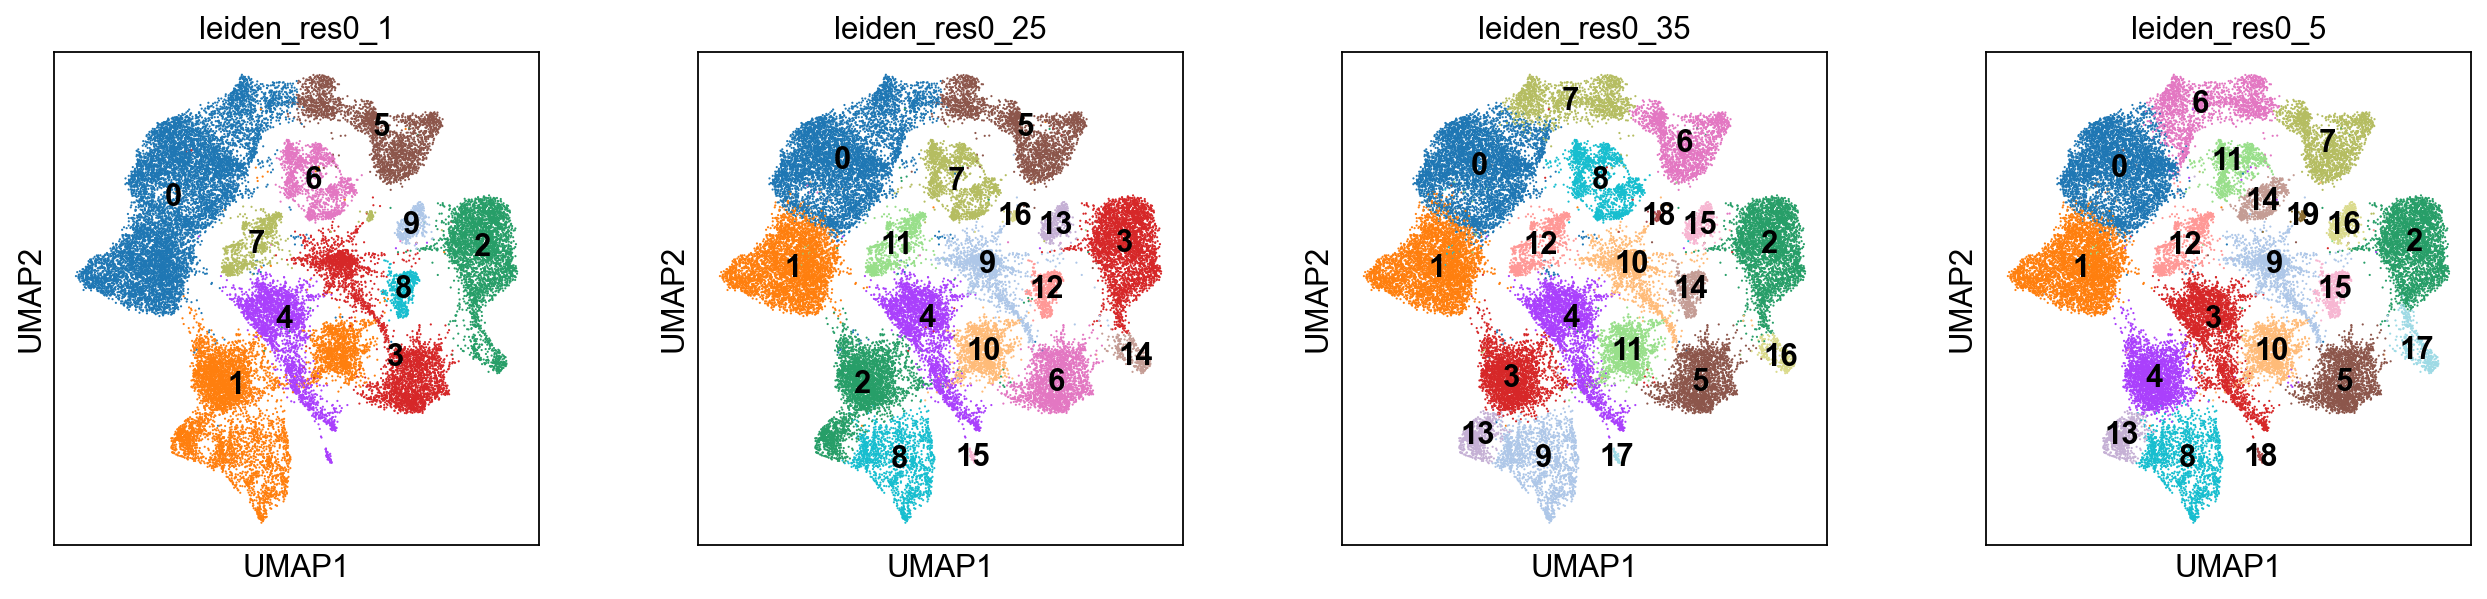

In [27]:
# Perform unbiased leiden clustering on batch-corrected data
sc.tl.leiden(adata_scvi, key_added='leiden_res0_25', resolution=0.25)
sc.tl.leiden(adata_scvi, key_added="leiden_res0_35", resolution=0.35)
sc.tl.leiden(adata_scvi, key_added='leiden_res0_1', resolution=0.1)
sc.tl.leiden(adata_scvi, key_added='leiden_res0_5', resolution=0.5)
sc.pl.umap(adata_scvi, color=['leiden_res0_1','leiden_res0_25', 'leiden_res0_35', 'leiden_res0_5'], legend_loc='on data')

In [63]:
adata_scvi.write(f'{data_path}/adata_scvi_xenium.h5ad')